In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
customer = pd.read_csv("../data/raw/datathon-2026-round-1/customers.csv")
geography = pd.read_csv("../data/raw/datathon-2026-round-1/geography.csv")
inventory = pd.read_csv("../data/raw/datathon-2026-round-1/inventory.csv")
order_items = pd.read_csv("../data/raw/datathon-2026-round-1/order_items.csv" , low_memory= False)
order = pd.read_csv("../data/raw/datathon-2026-round-1/orders.csv")
payment = pd.read_csv("../data/raw/datathon-2026-round-1/payments.csv")
product = pd.read_csv("../data/raw/datathon-2026-round-1/products.csv")
promotion = pd.read_csv("../data/raw/datathon-2026-round-1/promotions.csv")
returns = pd.read_csv("../data/raw/datathon-2026-round-1/returns.csv")
review = pd.read_csv("../data/raw/datathon-2026-round-1/reviews.csv")
sales = pd.read_csv("../data/raw/datathon-2026-round-1/sales.csv")
shipment = pd.read_csv("../data/raw/datathon-2026-round-1/shipments.csv")
web_traffic = pd.read_csv("../data/raw/datathon-2026-round-1/web_traffic.csv")

## chart2a
#### Chuẩn bị dữ liệu 

In [4]:
# ── Join orders → customers ───────────
df = order.merge(
    customer[['customer_id', 'acquisition_channel']],
    on='customer_id', how='left'
)

# ── Revenue từ order_items ────────────
order_items['revenue'] = (
    order_items['unit_price'] * order_items['quantity']
)
order_rev = order_items.groupby('order_id')['revenue'].sum().reset_index()
df = df.merge(order_rev, on='order_id', how='left')

# ── customers_count & revenue_per_customer ───────────────
base = (
    df.groupby('acquisition_channel')
    .agg(
        customers_count=('customer_id', 'nunique'),
        total_revenue=('revenue', 'sum'),
    )
    .reset_index()
)
# key 
base['revenue_per_customer'] = base['total_revenue'] / base['customers_count']

# ── retention_rate: % khách có ≥2 đơn trong 180 ngày đầu 
first_order = (
    df.groupby('customer_id')['order_date']
    .min().rename('first_order_date').reset_index()
)
df2 = df.merge(first_order, on='customer_id')
df2["order_date"] = pd.to_datetime(df2['order_date'])
df2["first_order_date"] = pd.to_datetime(df2["first_order_date"])
df2['days_since_first'] = (df2['order_date'] - df2['first_order_date']).dt.days
df_6m = df2[df2['days_since_first'] <= 180]

order_count_6m = (
    df_6m.groupby(['customer_id', 'acquisition_channel'])['order_id']
    .nunique().reset_index()
    .rename(columns={'order_id': 'orders_6m'})
)
retention = (
    order_count_6m.groupby('acquisition_channel')["orders_6m"]
    .apply(lambda x: (x >= 2).sum() / len(x) * 100)
    .rename('retention_rate').reset_index()
)

# ── avg_inter_order_gap (ngày trung bình giữa 2 lần mua) 
df_sorted = df.sort_values(['customer_id', 'order_date'])
df_sorted['prev_date'] = df_sorted.groupby('customer_id')['order_date'].shift(1)
df_sorted["order_date"] = pd.to_datetime(df_sorted["order_date"])
df_sorted["prev_date"] = pd.to_datetime(df_sorted['prev_date'])
df_sorted['gap'] = (df_sorted['order_date'] - df_sorted['prev_date']).dt.days
gap = (
    df_sorted.dropna(subset=['gap'])
    .groupby('acquisition_channel')['gap']
    .mean().rename('avg_inter_order_gap').reset_index()
)

# ── return_rate: % đơn bị trả ─────────
returned_orders = set(returns['order_id'].unique())
df['is_returned'] = df['order_id'].isin(returned_orders).astype(int)
ret_rate = (
    df.groupby('acquisition_channel')['is_returned']
    .apply(lambda x: x.sum() / len(x) * 100)
    .rename('return_rate').reset_index()
)

# ── Gộp tất cả ─────
metrics = (
    base
    .merge(retention, on='acquisition_channel')
    .merge(gap,       on='acquisition_channel')
    .merge(ret_rate,  on='acquisition_channel')
# key     .drop(columns=['total_revenue'])
)
metrics = metrics.round(2)
metrics

,acquisition_channel,customers_count,total_revenue,revenue_per_customer,retention_rate,avg_inter_order_gap,return_rate
0,direct,7337,1.310930e+09,178673.91,28.38,286.92,5.61
1,email_campaign,10886,1.967111e+09,180701.00,28.18,284.56,5.72
2,organic_search,26950,4.937572e+09,183212.31,27.91,284.35,5.59
3,paid_search,17999,3.271723e+09,181772.46,27.62,285.41,5.57
4,referral,9072,1.634969e+09,180221.50,27.20,287.04,5.45
5,social_media,18002,3.308171e+09,183766.87,28.06,287.01,5.51


### vẽ hình 

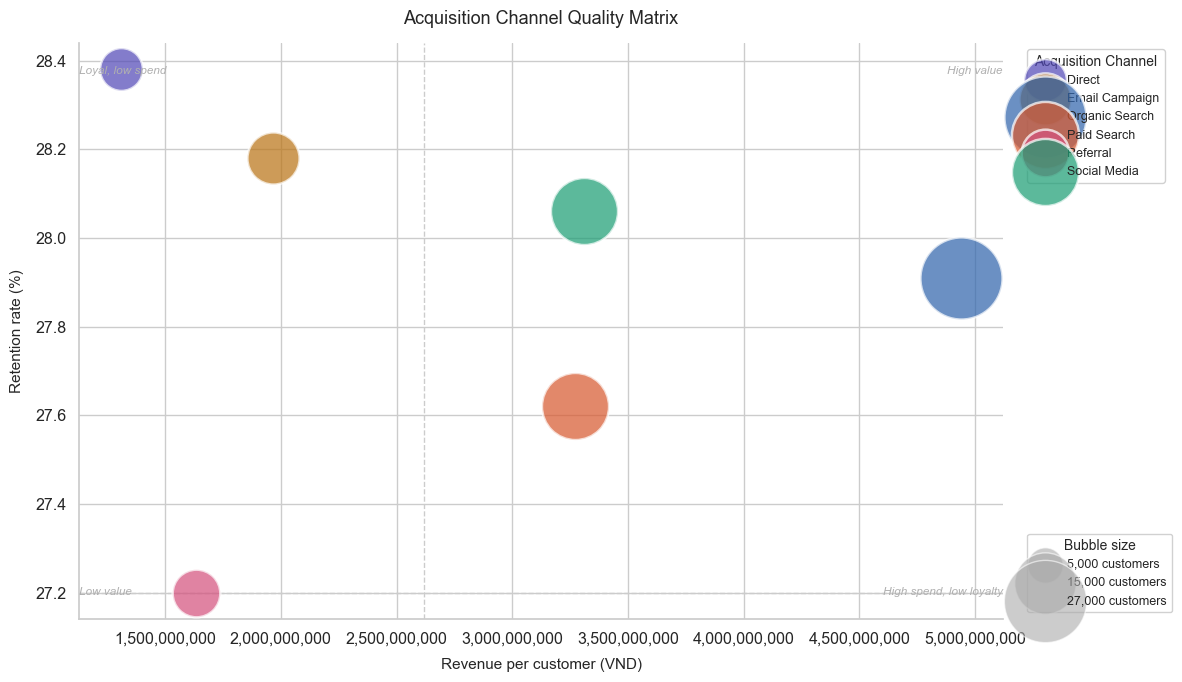

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)
fig, ax = plt.subplots(figsize=(12, 7))
#gan mau va nhan 
COLORS = {
    'organic_search' : '#3266ad',
    'social_media'   : '#1D9E75',
    'paid_search'    : '#D85A30',
    'email_campaign' : '#BA7517',
    'direct'         : '#534AB7',
    'referral'       : '#D4537E',
}

LABELS = {
    'organic_search' : 'Organic Search',
    'social_media'   : 'Social Media',
    'paid_search'    : 'Paid Search',
    'email_campaign' : 'Email Campaign',
    'direct'         : 'Direct',
    'referral'       : 'Referral',
}

max_count = metrics['customers_count'].max()
metrics['bubble_size'] = (metrics['customers_count'] / max_count) * 3500

# Vẽ các bong bóng 
for _, row in metrics.iterrows():
    ch = row['acquisition_channel']
    ax.scatter(   
        row['total_revenue'],
        row['retention_rate'],
        s=row['bubble_size'],
        color=COLORS.get(ch, '#888'),
        alpha=0.72,
        edgecolors='white',
        linewidths=1.8,
        zorder=3,
        label=LABELS.get(ch, ch) # THÊM LABEL VÀO ĐÂY ĐỂ TẠO BẢNG CHÚ GIẢI
    )

# ── Quadrant lines ───────────────────────────────────────────────────────────
mid_x = metrics['total_revenue'].median()
mid_y = metrics['retention_rate'].min()

ax.axvline(mid_x, color='#cccccc', lw=1, ls='--', zorder=1)
ax.axhline(mid_y, color='#cccccc', lw=1, ls='--', zorder=1)

xl = ax.get_xlim()
yl = ax.get_ylim()
quad_kw = dict(fontsize=8.5, color='#b0b0b0', style='italic')
ax.text(xl[1] - 200, yl[1] - 0.05, 'High value',               ha='right', va='top',    **quad_kw)
ax.text(xl[0] + 200, yl[1] - 0.05, 'Loyal, low spend',         ha='left',  va='top',    **quad_kw)
ax.text(xl[1] - 200, yl[0] + 0.05, 'High spend, low loyalty',  ha='right', va='bottom', **quad_kw)
ax.text(xl[0] + 200, yl[0] + 0.05, 'Low value',                ha='left',  va='bottom', **quad_kw)


#
legend_channel = ax.legend(
    title='Acquisition Channel', 
    loc='upper left', 
    bbox_to_anchor=(1.02, 1), 
    fontsize=9, 
    title_fontsize=10, 
    frameon=True, 
    framealpha=0.9
)
ax.add_artist(legend_channel) 


size_handles = []
for ref in [5000, 15000, 27000]:
    # Tạo các scatter ảo để làm ký hiệu size
    h = ax.scatter([], [], s=(ref/max_count)*3500,
               color='#aaa', alpha=0.6, edgecolors='white', lw=1,
               label=f'{ref:,} customers')
    size_handles.append(h)

ax.legend(
    handles=size_handles, 
    title='Bubble size', 
    loc='lower left', 
    bbox_to_anchor=(1.02, 0), 
    fontsize=9,
    title_fontsize=10, 
    frameon=True, 
    framealpha=0.9
)

# ── Axes formatting ──────────────────────────────────────────────────────────
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Revenue per customer (VND)', fontsize=11, labelpad=8)
ax.set_ylabel('Retention rate (%)', fontsize=11, labelpad=8)
ax.set_title('Acquisition Channel Quality Matrix',
             fontsize=13, fontweight='500', pad=14)

sns.despine()
plt.tight_layout()
plt.savefig('acquisition_quality_matrix.png', dpi=150, bbox_inches='tight')
plt.savefig("../reports/figures/char2a.png")
plt.show()

## Chart 2b 



In [ ]:
# ── Chỉ lấy đơn hợp lệ (bỏ cancelled / created) ────────────────────────────
valid = ['delivered', 'returned', 'shipped', 'paid']
df = order[order['order_status'].isin(valid)].copy()

# ── Cohort = tháng đặt đơn đầu tiên ────────────────────────────────────────
df["order_date"] = pd.to_datetime(df["order_date"])
df = df[df["order_date"].between("2020-01-01", "2022-12-31")]
df['order_month'] = df['order_date'].dt.to_period('M')
first_order = (
    df.groupby('customer_id')['order_month']
    .min()
    .rename('cohort_month')
    .reset_index()
)
df = df.merge(first_order, on='customer_id')

# ── Số tháng sau lần mua đầu (0 = tháng đầu, 1 = tháng tiếp…) ─────────────
df['month_number'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)
df = df[df['month_number'] <= 12]

# ── Cohort size = số khách unique ở tháng đầu tiên sau lần mua đầu  ─────────────────────────────────
cohort_size = (
    df[df['month_number'] == 0]
    .groupby('cohort_month')['customer_id']
    .nunique()
    .rename('cohort_size')
)

# ── Active customers per (cohort, month) ────────────────────────────────────
cohort_data = (
    df.groupby(['cohort_month', 'month_number'])['customer_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_id': 'active_customers'})
)
cohort_data = cohort_data.merge(cohort_size, on='cohort_month')
# công thức tích retention_rate : 
cohort_data['retention_rate'] = (
    cohort_data['active_customers'] / cohort_data['cohort_size'] * 100
)

# ── Pivot → matrix (bỏ month 0 vì luôn = 100%) ─────────────────────────────
pivot = (
    cohort_data[cohort_data['month_number'] >= 1]
    .pivot_table(index='cohort_month', columns='month_number', values='retention_rate')
)
pivot.index = pivot.index.astype(str)
pivot.columns = [f'M+{c}' for c in pivot.columns]

# ── Gộp theo năm (median) cho dễ đọc ────────────────────────────────────────
pivot['year'] = pivot.index.str[:4]
pivot_year = pivot.groupby('year').median(numeric_only=True)
pivot_year

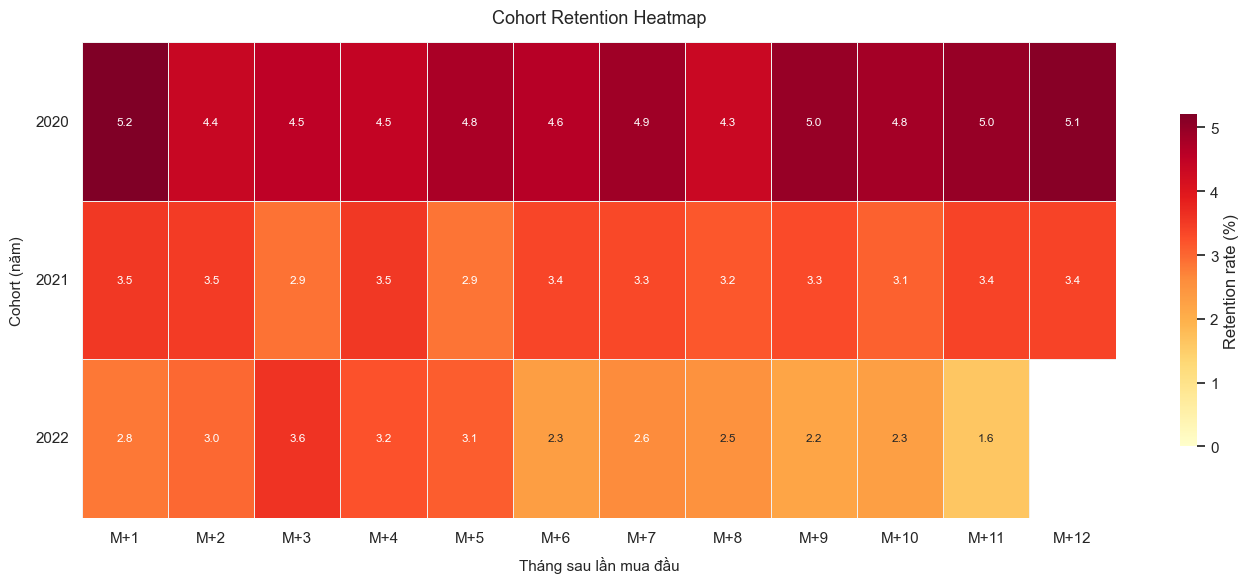

In [ ]:

sns.set_theme(style='white', font_scale=1.0)

fig, ax = plt.subplots(figsize=(14, 6))

mask = pivot_year.isna()

sns.heatmap(
    pivot_year,
    ax=ax,
    mask=mask,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 8.5, 'weight': '500'},
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='#f0f0f0',
    cbar_kws={'label': 'Retention rate (%)', 'shrink': 0.7},
    vmin=0,
)

# Tô ô NaN màu xám nhạt
sns.heatmap(
    pivot_year,
    ax=ax,
    mask=~mask,
    annot=False,
    cmap=['#f5f5f5'],
    linewidths=0.4,
    linecolor='#f0f0f0',
    cbar=False,
    vmin=0, vmax=1,
)

ax.set_title('Cohort Retention Heatmap',
             fontsize=13, fontweight='500', pad=14)
ax.set_xlabel('Tháng sau lần mua đầu', fontsize=11, labelpad=8)
ax.set_ylabel('Cohort (năm)', fontsize=11, labelpad=8)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.savefig("../reports/figures/char2b_year.png")
plt.tight_layout()
plt.show()

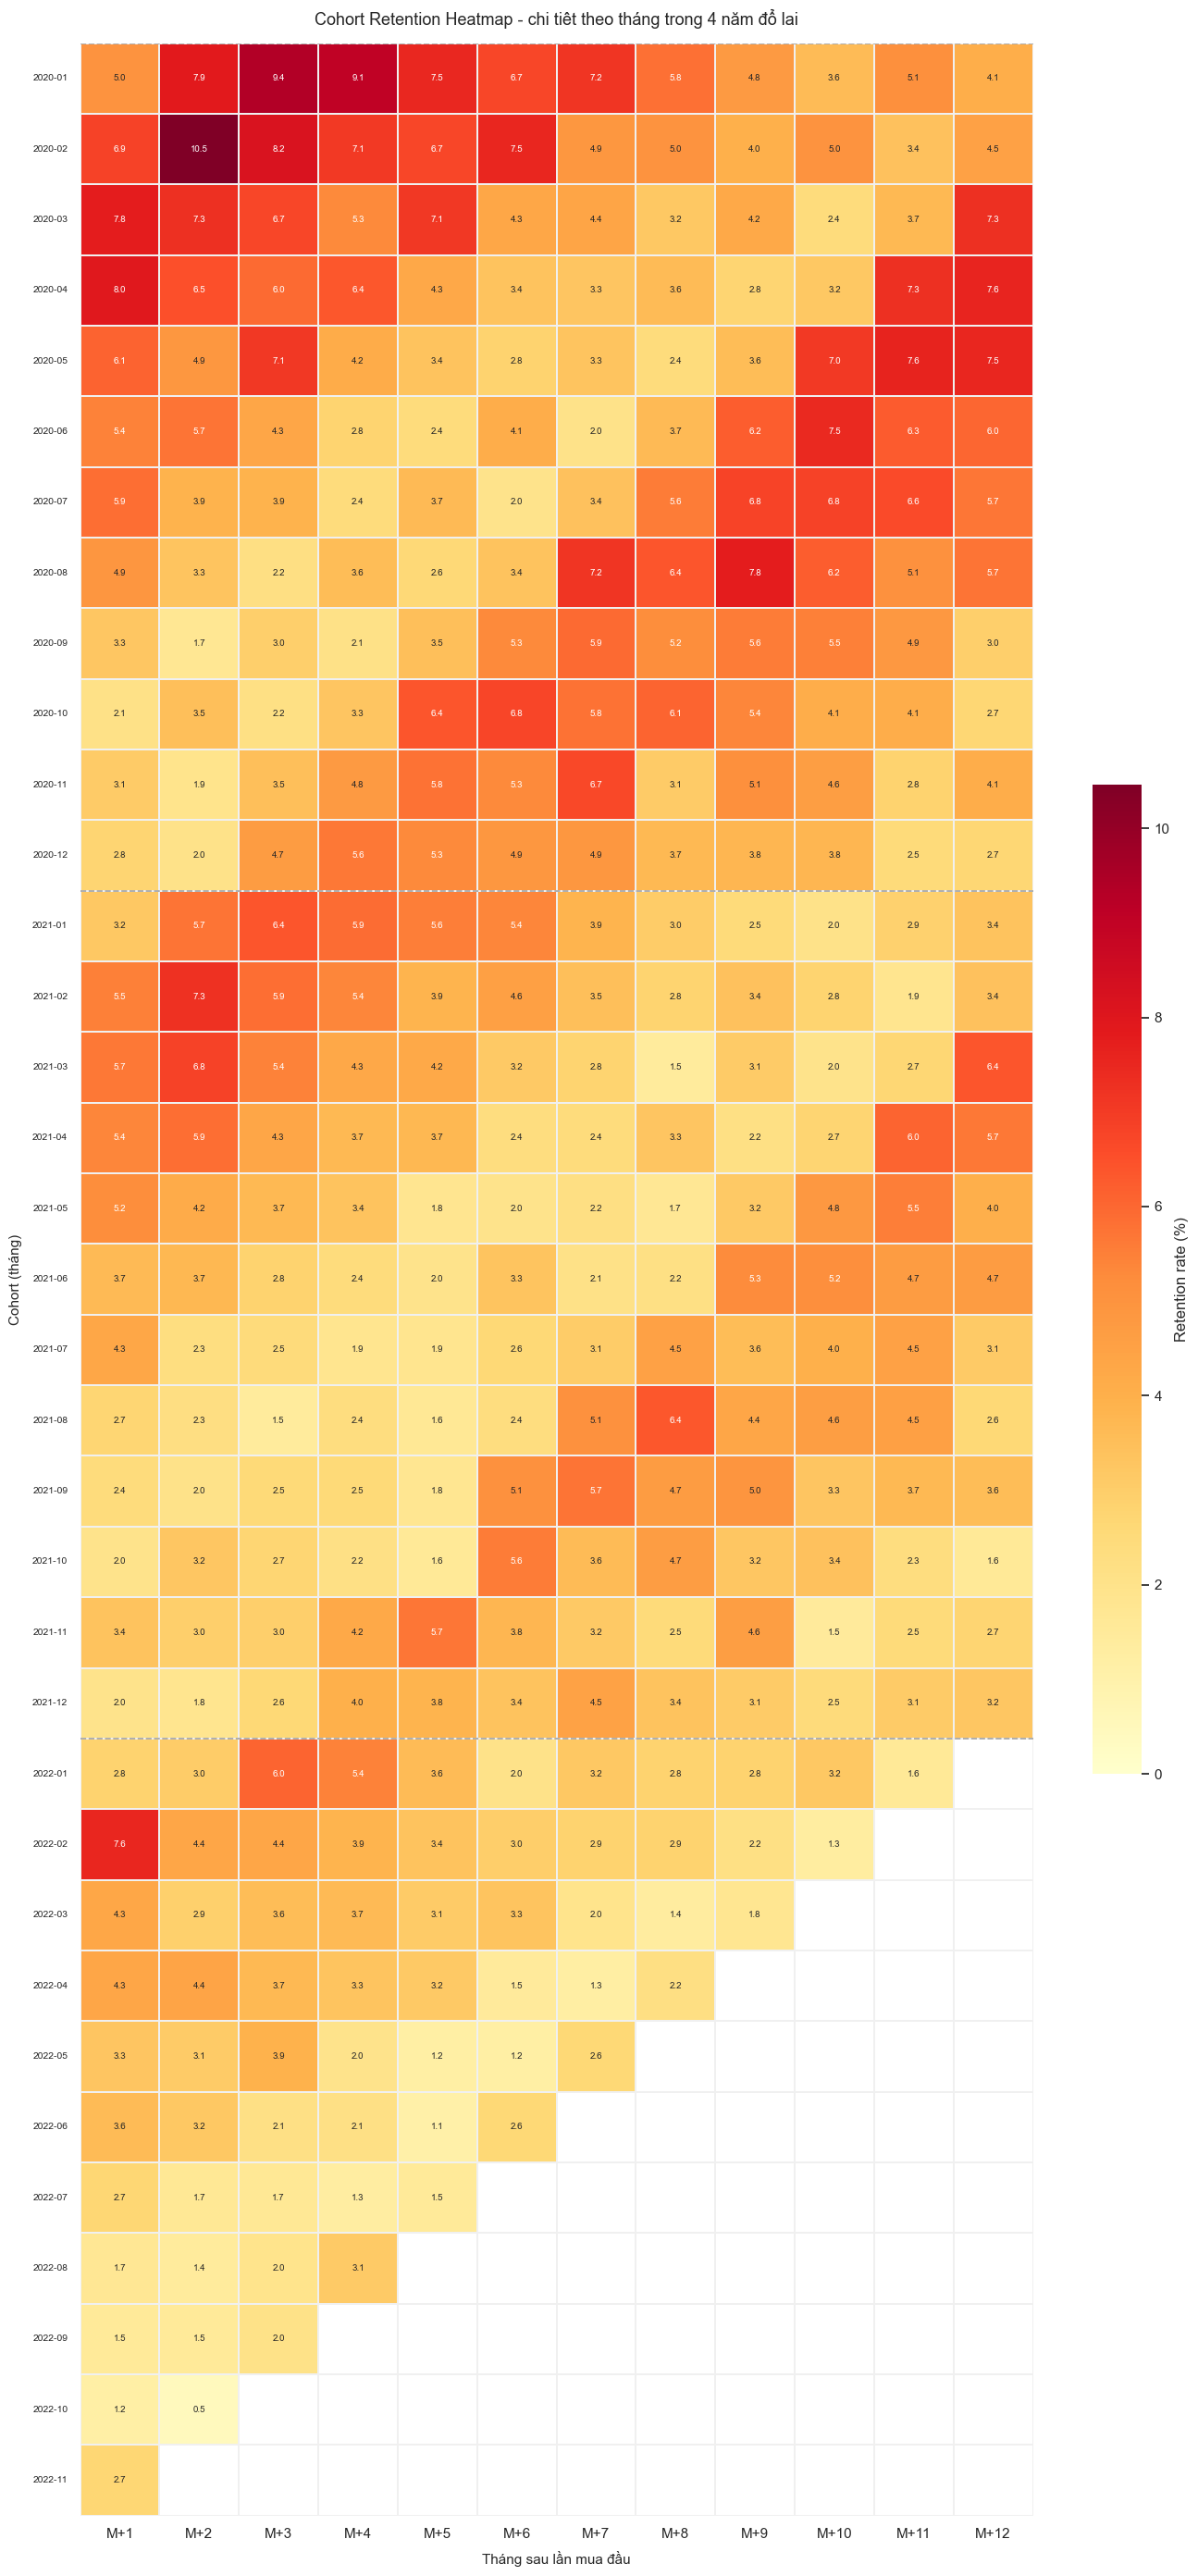

In [9]:
pivot_plot = pivot.drop(columns='year')
mask2 = pivot_plot.isna()

fig, ax = plt.subplots(figsize=(14, 28))

sns.heatmap(
    pivot_plot,
    ax=ax,
    mask=mask2,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 7},
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='#f0f0f0',
    cbar_kws={'label': 'Retention rate (%)', 'shrink': 0.4},
    vmin=0,
)
sns.heatmap(
    pivot_plot,
    ax=ax,
    mask=~mask2,
    annot=False,
    cmap=['#f5f5f5'],
    linewidths=0.3,
    linecolor='#f0f0f0',
    cbar=False,
    vmin=0, vmax=1,
)

# Vẽ đường phân cách theo năm
year_boundaries = (
    pivot_plot.index.str[:4]
    .to_series()
    .reset_index(drop=True)
    .ne(pivot_plot.index.str[:4]
        .to_series()
        .reset_index(drop=True)
        .shift())
    .where(lambda x: x)
    .dropna()
    .index
    .tolist()
)
for boundary in year_boundaries:
    ax.axhline(boundary, color='#555', linewidth=1.2, linestyle='--', alpha=0.5)

ax.set_title('Cohort Retention Heatmap - chi tiêt theo tháng trong 4 năm đổ lai',
             fontsize=13, fontweight='500', pad=14)
ax.set_xlabel('Tháng sau lần mua đầu', fontsize=11, labelpad=8)
ax.set_ylabel('Cohort (tháng)', fontsize=11, labelpad=8)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0, labelsize=7.5)
plt.savefig('../reports/figures/char2b_2.png')
plt.tight_layout()
plt.show()

### gen du lieu tu nam 2012 toi 2022 de ve cohort curve 

In [ ]:
# ── Chỉ lấy đơn hợp lệ (bỏ cancelled / created) ────────────────────────────
valid = ['delivered', 'returned', 'shipped', 'paid']
df = order[order['order_status'].isin(valid)].copy()

# ── Cohort = tháng đặt đơn đầu tiên ────────────────────────────────────────
df["order_date"] = pd.to_datetime(df["order_date"])
df['order_month'] = df['order_date'].dt.to_period('M')
first_order = (
    df.groupby('customer_id')['order_month']
    .min()
    .rename('cohort_month')
    .reset_index()
)
df = df.merge(first_order, on='customer_id')

# ── Số tháng sau lần mua đầu (0 = tháng đầu, 1 = tháng tiếp…) ─────────────
df['month_number'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)
df = df[df['month_number'] <= 12]

# ── Cohort size = số khách unique ở tháng đầu tiên sau lần mua đầu  ─────────────────────────────────
cohort_size = (
    df[df['month_number'] == 0]
    .groupby('cohort_month')['customer_id']
    .nunique()
    .rename('cohort_size')
)

# ── Active customers per (cohort, month) ────────────────────────────────────
cohort_data = (
    df.groupby(['cohort_month', 'month_number'])['customer_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_id': 'active_customers'})
)
cohort_data = cohort_data.merge(cohort_size, on='cohort_month')
# công thức tích retention_rate : 
cohort_data['retention_rate'] = (
    cohort_data['active_customers'] / cohort_data['cohort_size'] * 100
)

# ── Pivot → matrix (bỏ month 0 vì luôn = 100%) ─────────────────────────────
pivot = (
    cohort_data[cohort_data['month_number'] >= 1]
    .pivot_table(index='cohort_month', columns='month_number', values='retention_rate')
)
pivot.index = pivot.index.astype(str)
pivot.columns = [f'M+{c}' for c in pivot.columns]

# ── Gộp theo năm (median) cho dễ đọc ────────────────────────────────────────
pivot['year'] = pivot.index.str[:4]
pivot_year = pivot.groupby('year').median(numeric_only=True)
pivot_year

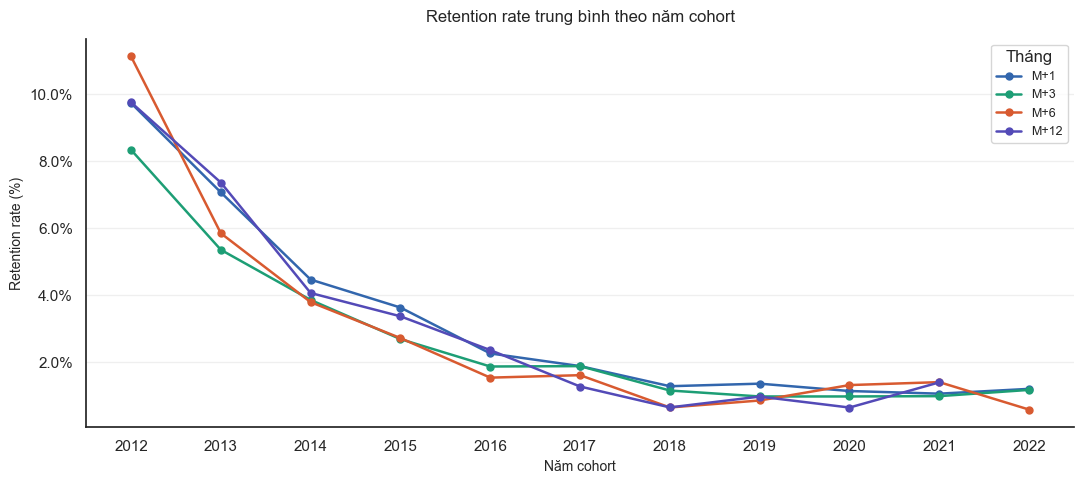

In [12]:
trend = pivot_year[['M+1', 'M+3', 'M+6', 'M+12']].copy()

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#3266ad', '#1D9E75', '#D85A30', '#534AB7']

for col, color in zip(trend.columns, colors):
    ax.plot(trend.index, trend[col], marker='o', label=col,
            color=color, linewidth=1.8, markersize=5)

ax.set_title('Retention rate trung bình theo năm cohort',
             fontsize=12, fontweight='500', pad=12)
ax.set_xlabel('Năm cohort', fontsize=10)
ax.set_ylabel('Retention rate (%)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(title='Tháng', fontsize=9)
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig("../reports/figures/chart2b_3.png")
plt.show()

## Char2c
